--- Фаззификация входных данных ---

Влажность почвы = 45.0%:
  Степень принадлежности к 'Сухая влажность' (СВ): 0.000
  Степень принадлежности к 'Оптимальная влажность' (ОВ): 1.000
  Степень принадлежности к 'Высокая влажность' (ВВ): 0.000

Температура в помещении = 22.0°C:
  Степень принадлежности к 'Низкая температура' (НТ): 0.000
  Степень принадлежности к 'Средняя температура' (СТ): 0.857
  Степень принадлежности к 'Высокая температура' (ВТ): 0.000

Объем полива (для примера) = 100.0 мл:
  Степень принадлежности к 'Очень маленький полив' (ОМП): 0.000
  Степень принадлежности к 'Маленький полив' (МП): 0.000
  Степень принадлежности к 'Средний полив' (СП): 1.000
  Степень принадлежности к 'Высокий полив' (ВП): 0.000
  Степень принадлежности к 'Очень высокий полив' (ОВП): 0.000

--- Построение графиков функций принадлежности ---


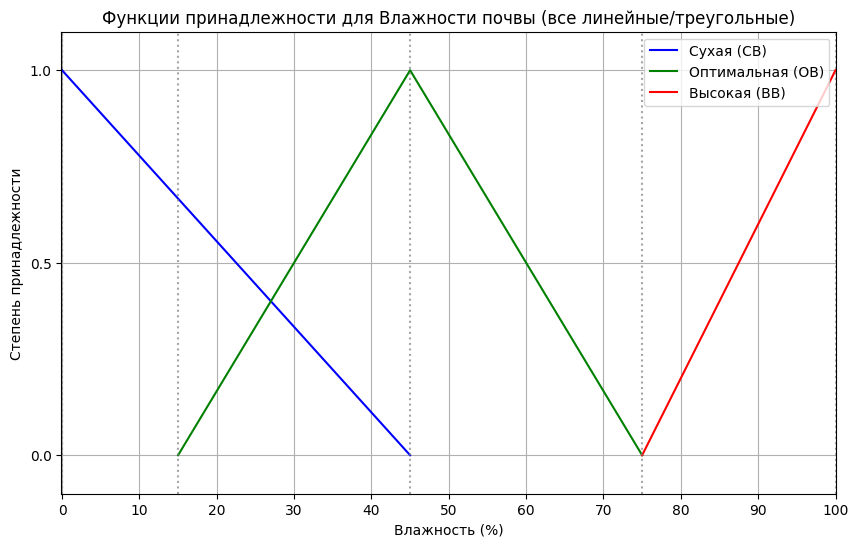

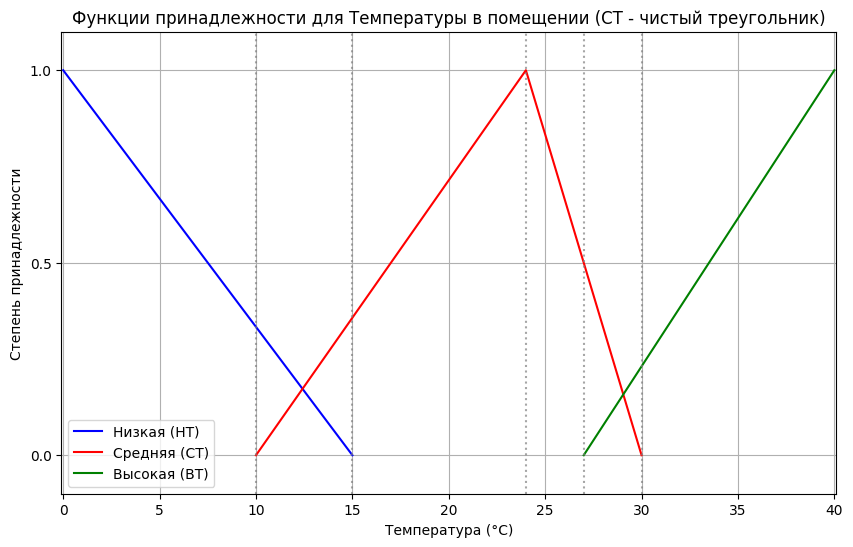

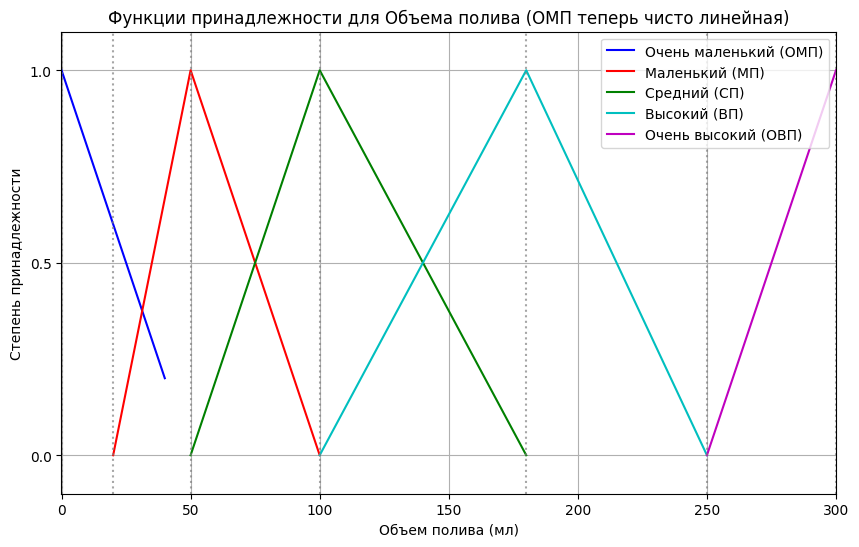

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# ФУНКЦИИ ПРИНАДЛЕЖНОСТИ ДЛЯ ВХОДНОЙ ПЕРЕМЕННОЙ: "Влажность почвы" (%)
# (ИСПРАВЛЕНО: СВ и ОВ теперь чисто линейные/треугольные)
# =========================================================================

def fuzzy_soil_dry_linear_smooth(x): # ИСПРАВЛЕНО: новое имя, чтобы отразить отсутствие плато
    """
    Функция принадлежности для терма "Сухая влажность" (СВ)
    Теперь чисто линейно убывающая, достигает 1.0 только в x=0.
    """
    if x <= 0:
        return 1.0
    elif 0 < x <= 45: # Убывает до 0 на 45
        return (45 - x) / 45.0 # Убывает от 1 до 0
    else:
        return 0.0

def fuzzy_soil_optimal_triangle(x): # ИСПРАВЛЕНО: новое имя, ОВ - чистый треугольник
    """
    Функция принадлежности для терма "Оптимальная влажность" (ОВ)
    Теперь чисто треугольная форма (без плато на уровне 1).
    """
    if x <= 15 or x >= 75: # Начинает от 0 в 15, заканчивает в 75
        return 0.0
    elif 15 < x <= 45: # Рост от 0 до 1 (вершина в 45)
        return (x - 15) / 30.0
    elif 45 < x <= 75: # Убывание от 1 до 0
        return (75 - x) / 30.0
    else:
        return 0.0

def fuzzy_soil_high_linear_smooth(x): # ИСПРАВЛЕНО: новое имя
    """
    Функция принадлежности для терма "Высокая влажность" (ВВ)
    Линейная, возрастающая от 0 до 1.
    """
    if x <= 75:
        return 0.0
    elif 75 < x <= 100:
        return (x - 75) / 25.0
    else: # x > 100
        return 1.0 # Крайний терм, может быть плато в конце диапазона

# =========================================================================
# ФУНКЦИИ ПРИНАДЛЕЖНОСТИ ДЛЯ ВХОДНОЙ ПЕРЕМЕННОЙ: "Температура в помещении" (°C)
# (Без изменений, СТ - чистый треугольник)
# =========================================================================

def fuzzy_temp_low_formula(x):
    if 0 <= x <= 15:
        return -1/15 * x + 1
    else:
        return 0.0

def fuzzy_temp_medium_formula(x):
    if 10 <= x <= 24:
        return (1/14 * x) - (5/7)
    elif 24 < x <= 30:
        return (-1/6 * x) + 5
    else:
        return 0.0

def fuzzy_temp_high_formula(x):
    if 27 <= x <= 40:
        return (1/13 * x) - (27/13)
    else:
        return 0.0

# =========================================================================
# ФУНКЦИИ ПРИНАДЛЕЖНОСТИ ДЛЯ ВЫХОДНОЙ ПЕРЕМЕННОЙ: "Объем полива" (мл)
# (ИСПРАВЛЕНО: ОМП теперь чисто линейная. Остальные - как в предыдущей версии)
# =========================================================================

def fuzzy_volume_very_small_linear_smooth(y): # ИСПРАВЛЕНО: новое имя
    """
    Функция принадлежности для терма "Очень маленький полив" (ОМП)
    Теперь чисто линейно убывающая, достигает 1.0 только в y=0.
    """
    if y <= 0:
        return 1.0
    elif 0 < y <= 50: # Убывает до 0 на 50
        return (50 - y) / 50.0 # Убывает от 1 до 0
    else:
        return 0.0

def fuzzy_volume_small_linear_only(y):
    if y <= 20 or y >= 100:
        return 0.0
    elif 20 < y <= 50:
        return (y - 20) / 30.0
    elif 50 < y <= 100:
        return (100 - y) / 50.0
    else:
        return 0.0

def fuzzy_volume_medium_linear_only(y):
    if y <= 50 or y >= 180:
        return 0.0
    elif 50 < y <= 100:
        return (y - 50) / 50.0
    elif 100 < y <= 180:
        return (180 - y) / 80.0
    else:
        return 0.0

def fuzzy_volume_high_linear_only(y):
    if y <= 100 or y >= 250:
        return 0.0
    elif 100 < y <= 180:
        return (y - 100) / 80.0
    elif 180 < y <= 250:
        return (250 - y) / 70.0
    else:
        return 0.0

def fuzzy_volume_very_high_linear_only(y):
    if y <= 250:
        return 0.0
    elif 250 < y <= 300:
        return (y - 250) / 50.0
    else:
        return 1.0


# =========================================================================
# ГЛАВНЫЙ СКРИПТ: Тестирование функций принадлежности и визуализация
# =========================================================================

if __name__ == "__main__":
    print("--- Фаззификация входных данных ---")

    # --- Пример входных данных ---
    soil_humidity_test = 45  # %
    room_temperature_test = 22  # C
    output_volume_test = 100 # ml

    # --- Фаззификация Влажности почвы ---
    mu_soil_dry = fuzzy_soil_dry_linear_smooth(soil_humidity_test) # Использование новой функции
    mu_soil_optimal = fuzzy_soil_optimal_triangle(soil_humidity_test) # Использование новой функции
    mu_soil_high = fuzzy_soil_high_linear_smooth(soil_humidity_test) # Использование новой функции

    print(f"\nВлажность почвы = {soil_humidity_test:.1f}%:")
    print(f"  Степень принадлежности к 'Сухая влажность' (СВ): {mu_soil_dry:.3f}")
    print(f"  Степень принадлежности к 'Оптимальная влажность' (ОВ): {mu_soil_optimal:.3f}")
    print(f"  Степень принадлежности к 'Высокая влажность' (ВВ): {mu_soil_high:.3f}")

    # --- Фаззификация Температуры в помещении ---
    mu_temp_low = fuzzy_temp_low_formula(room_temperature_test)
    mu_temp_medium = fuzzy_temp_medium_formula(room_temperature_test)
    mu_temp_high = fuzzy_temp_high_formula(room_temperature_test)

    print(f"\nТемпература в помещении = {room_temperature_test:.1f}°C:")
    print(f"  Степень принадлежности к 'Низкая температура' (НТ): {mu_temp_low:.3f}")
    print(f"  Степень принадлежности к 'Средняя температура' (СТ): {mu_temp_medium:.3f}")
    print(f"  Степень принадлежности к 'Высокая температура' (ВТ): {mu_temp_high:.3f}")

    # --- Фаззификация Объема полива (для примера) ---
    mu_vol_vs = fuzzy_volume_very_small_linear_smooth(output_volume_test) # Использование новой функции
    mu_vol_s = fuzzy_volume_small_linear_only(output_volume_test)
    mu_vol_m = fuzzy_volume_medium_linear_only(output_volume_test)
    mu_vol_h = fuzzy_volume_high_linear_only(output_volume_test)
    mu_vol_vh = fuzzy_volume_very_high_linear_only(output_volume_test)

    print(f"\nОбъем полива (для примера) = {output_volume_test:.1f} мл:")
    print(f"  Степень принадлежности к 'Очень маленький полив' (ОМП): {mu_vol_vs:.3f}")
    print(f"  Степень принадлежности к 'Маленький полив' (МП): {mu_vol_s:.3f}")
    print(f"  Степень принадлежности к 'Средний полив' (СП): {mu_vol_m:.3f}")
    print(f"  Степень принадлежности к 'Высокий полив' (ВП): {mu_vol_h:.3f}")
    print(f"  Степень принадлежности к 'Очень высокий полив' (ОВП): {mu_vol_vh:.3f}")


    print("\n--- Построение графиков функций принадлежности ---")

    step = 0.1

    # =====================================================================
    # График для Влажности почвы (все чисто линейные/треугольные)
    # =====================================================================
    x_soil_vals = np.arange(0, 100.1, step)
    plt.figure(figsize=(10, 6))

    # Сухая: [0, 45]
    idx_dry_end = int(45 / step) + 1
    plt.plot(x_soil_vals[0:idx_dry_end], [fuzzy_soil_dry_linear_smooth(x) for x in x_soil_vals[0:idx_dry_end]], 'b', linewidth=1.5, label='Сухая (СВ)')

    # Оптимальная: [15, 75]
    idx_optimal_start = int(15 / step)
    idx_optimal_end = int(75 / step) + 1
    plt.plot(x_soil_vals[idx_optimal_start:idx_optimal_end], [fuzzy_soil_optimal_triangle(x) for x in x_soil_vals[idx_optimal_start:idx_optimal_end]], 'g', linewidth=1.5, label='Оптимальная (ОВ)')

    # Высокая: [75, 100]
    idx_high_start = int(75 / step)
    idx_high_end = int(100 / step) + 1
    plt.plot(x_soil_vals[idx_high_start:idx_high_end], [fuzzy_soil_high_linear_smooth(x) for x in x_soil_vals[idx_high_start:idx_high_end]], 'r', linewidth=1.5, label='Высокая (ВВ)')

    # Добавляем вертикальные линии для ключевых точек
    plt.axvline(x=0, color='gray', linestyle=':', alpha=0.7) # Новая точка для СВ
    plt.axvline(x=15, color='gray', linestyle=':', alpha=0.7)
    plt.axvline(x=45, color='gray', linestyle=':', alpha=0.7)
    plt.axvline(x=75, color='gray', linestyle=':', alpha=0.7)
    plt.axvline(x=100, color='gray', linestyle=':', alpha=0.7) # Новая точка для ВВ

    plt.title('Функции принадлежности для Влажности почвы (все линейные/треугольные)')
    plt.xlabel('Влажность (%)')
    plt.ylabel('Степень принадлежности')
    plt.ylim([-0.1, 1.1])
    plt.xlim([-0.1, 100.1])
    plt.xticks(np.arange(0, 101, 10))
    plt.yticks(np.arange(0, 1.1, 0.5))
    plt.legend()
    plt.grid(True)
    plt.show()

    # =====================================================================
    # График для Температуры в помещении (без изменений)
    # =====================================================================
    x_temp_vals = np.arange(0, 40.1, step)
    plt.figure(figsize=(10, 6))

    idx_nt_end = int(15 / step) + 1
    plt.plot(x_temp_vals[0:idx_nt_end], [fuzzy_temp_low_formula(x) for x in x_temp_vals[0:idx_nt_end]], 'b', linewidth=1.5, label='Низкая (НТ)')

    idx_ct_start = int(10 / step)
    idx_ct_end = int(30 / step) + 1
    plt.plot(x_temp_vals[idx_ct_start:idx_ct_end], [fuzzy_temp_medium_formula(x) for x in x_temp_vals[idx_ct_start:idx_ct_end]], 'r', linewidth=1.5, label='Средняя (СТ)')

    idx_ht_start = int(27 / step)
    idx_ht_end = int(40 / step) + 1
    plt.plot(x_temp_vals[idx_ht_start:idx_ht_end], [fuzzy_temp_high_formula(x) for x in x_temp_vals[idx_ht_start:idx_ht_end]], 'g', linewidth=1.5, label='Высокая (ВТ)')

    plt.axvline(x=10, color='gray', linestyle=':', alpha=0.7)
    plt.axvline(x=15, color='gray', linestyle=':', alpha=0.7)
    plt.axvline(x=24, color='gray', linestyle=':', alpha=0.7)
    plt.axvline(x=27, color='gray', linestyle=':', alpha=0.7)
    plt.axvline(x=30, color='gray', linestyle=':', alpha=0.7)

    plt.title('Функции принадлежности для Температуры в помещении (СТ - чистый треугольник)')
    plt.xlabel('Температура (°C)')
    plt.ylabel('Степень принадлежности')
    plt.ylim([-0.1, 1.1])
    plt.xlim([-0.1, 40.1])
    plt.xticks(np.arange(0, 41, 5))
    plt.yticks(np.arange(0, 1.1, 0.5))
    plt.legend()
    plt.grid(True)
    plt.show()

    # =====================================================================
    # График для Объема полива (ОМП теперь чисто линейная. ВП и ОВП остаются треугольниками.)
    # =====================================================================
    x_volume_vals = np.arange(0, 300.1, step)
    plt.figure(figsize=(10, 6))

    # Очень маленький: [0, 50]
    idx_vs_end = int(40 / step) + 1
    plt.plot(x_volume_vals[0:idx_vs_end], [fuzzy_volume_very_small_linear_smooth(y) for y in x_volume_vals[0:idx_vs_end]], 'b', linewidth=1.5, label='Очень маленький (ОМП)')

    # Маленький: [20, 100]
    idx_s_start = int(20 / step)
    idx_s_end = int(100 / step) + 1
    plt.plot(x_volume_vals[idx_s_start:idx_s_end], [fuzzy_volume_small_linear_only(y) for y in x_volume_vals[idx_s_start:idx_s_end]], 'r', linewidth=1.5, label='Маленький (МП)')

    # Средний: [50, 180]
    idx_m_start = int(50 / step)
    idx_m_end = int(180 / step) + 1
    plt.plot(x_volume_vals[idx_m_start:idx_m_end], [fuzzy_volume_medium_linear_only(y) for y in x_volume_vals[idx_m_start:idx_m_end]], 'g', linewidth=1.5, label='Средний (СП)')

    # Высокий: [100, 250]
    idx_h_start = int(100 / step)
    idx_h_end = int(250 / step) + 1
    plt.plot(x_volume_vals[idx_h_start:idx_h_end], [fuzzy_volume_high_linear_only(y) for y in x_volume_vals[idx_h_start:idx_h_end]], 'c', linewidth=1.5, label='Высокий (ВП)')

    # Очень высокий: [250, 300]
    idx_vh_start = int(250 / step)
    idx_vh_end = int(300 / step) + 1
    plt.plot(x_volume_vals[idx_vh_start:idx_vh_end], [fuzzy_volume_very_high_linear_only(y) for y in x_volume_vals[idx_vh_start:idx_vh_end]], 'm', linewidth=1.5, label='Очень высокий (ОВП)')

    # Добавляем вертикальные линии для ключевых точек
    plt.axvline(x=0, color='gray', linestyle=':', alpha=0.7) # Новая точка для ОМП
    plt.axvline(x=20, color='gray', linestyle=':', alpha=0.7)
    plt.axvline(x=50, color='gray', linestyle=':', alpha=0.7)
    plt.axvline(x=100, color='gray', linestyle=':', alpha=0.7)
    plt.axvline(x=180, color='gray', linestyle=':', alpha=0.7)
    plt.axvline(x=250, color='gray', linestyle=':', alpha=0.7)
    plt.axvline(x=300, color='gray', linestyle=':', alpha=0.7) # Новая точка для ОВП

    plt.title('Функции принадлежности для Объема полива (ОМП теперь чисто линейная)')
    plt.xlabel('Объем полива (мл)')
    plt.ylabel('Степень принадлежности')
    plt.ylim([-0.1, 1.1])
    plt.xlim([-0.1, 300.1])
    plt.xticks(np.arange(0, 301, 50))
    plt.yticks(np.arange(0, 1.1, 0.5))
    plt.legend()
    plt.grid(True)
    plt.show()